# Telecom Customer Churn — Retention Analysis

This notebook answers which subscribers are most likely to churn and where a retention budget should be spent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score


In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_total_charges = int(df['TotalCharges'].isna().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Data quality and KPI checks

In [3]:
print(df.shape)
print('Blank TotalCharges converted to NA:', missing_total_charges)
print('Overall churn rate:', round(df['ChurnFlag'].mean()*100, 1), '%')


(7043, 22)
Blank TotalCharges converted to NA: 11
Overall churn rate: 26.5 %


In [4]:
contract_summary = (df.groupby('Contract', as_index=False)
    .agg(customers=('customerID','count'), churn_rate=('ChurnFlag','mean'),
         mrr_lost=('MonthlyCharges', lambda x: x[df.loc[x.index, 'ChurnFlag'].eq(1)].sum())))
contract_summary['churn_rate_pct'] = contract_summary['churn_rate'] * 100
contract_summary.sort_values('churn_rate_pct', ascending=False)

,Contract,customers,churn_rate,mrr_lost,churn_rate_pct
0,Month-to-month,3875,0.427097,120847.10,42.709677
1,One year,1473,0.112695,14118.45,11.269518
2,Two year,1695,0.028319,4165.30,2.831858


## Segmentation

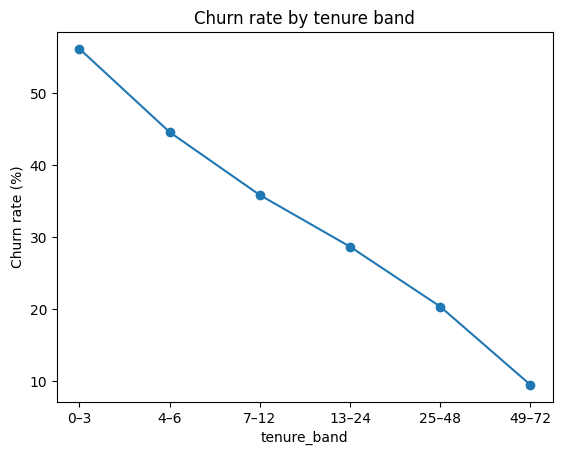

In [5]:
df['tenure_band'] = pd.cut(df['tenure'], [-1,3,6,12,24,48,72], labels=['0–3','4–6','7–12','13–24','25–48','49–72'])
tenure_summary = df.groupby('tenure_band', observed=False)['ChurnFlag'].mean().mul(100)
tenure_summary.plot(kind='line', marker='o', title='Churn rate by tenure band');
plt.ylabel('Churn rate (%)'); plt.show()

In [6]:
segment = (df.groupby(['InternetService','TechSupport'], as_index=False)
  .agg(customers=('customerID','count'), churn_rate=('ChurnFlag','mean')))
segment['churn_rate_pct'] = segment['churn_rate'] * 100
segment.sort_values('churn_rate_pct', ascending=False)

,InternetService,TechSupport,customers,churn_rate,churn_rate_pct
2,Fiber optic,No,2230,0.493722,49.372197
0,DSL,No,1243,0.277554,27.755430
3,Fiber optic,Yes,866,0.226328,22.632794
1,DSL,Yes,1178,0.096774,9.677419
4,No,No internet service,1526,0.074050,7.404980


## Logistic regression and random forest comparison

In [7]:
target = df['ChurnFlag']
features = ['tenure','MonthlyCharges','TotalCharges','Contract','InternetService','TechSupport','PaymentMethod','PaperlessBilling']
X_train, X_test, y_train, y_test = train_test_split(df[features], target, test_size=0.2, random_state=42, stratify=target)
num_cols = ['tenure','MonthlyCharges','TotalCharges']
cat_cols = [c for c in features if c not in num_cols]
preprocess = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
logit = Pipeline([('preprocess', preprocess), ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))])
forest = Pipeline([('preprocess', preprocess), ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', min_samples_leaf=5, n_jobs=-1))])
results = []
for name, estimator in [('Logistic regression', logit), ('Random forest', forest)]:
    estimator.fit(X_train, y_train)
    pred_prob = estimator.predict_proba(X_test)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)
    results.append({'model': name, 'roc_auc': roc_auc_score(y_test, pred_prob), 'churn_recall': recall_score(y_test, pred)})
results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df

,model,roc_auc,churn_recall
0,Logistic regression,0.836907,0.799465
1,Random forest,0.836508,0.737968


## Conclusion

The descriptive finding is stable across the analysis: month-to-month and early-tenure customers are the highest-priority retention segments. The models provide a reproducible way to rank customers for outreach, while the dashboard communicates the segment-level decision to a business audience.